In [2]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [3]:
# plotting settings
from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec
from importlib import reload

In [2]:
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.cluster_tuning import summary

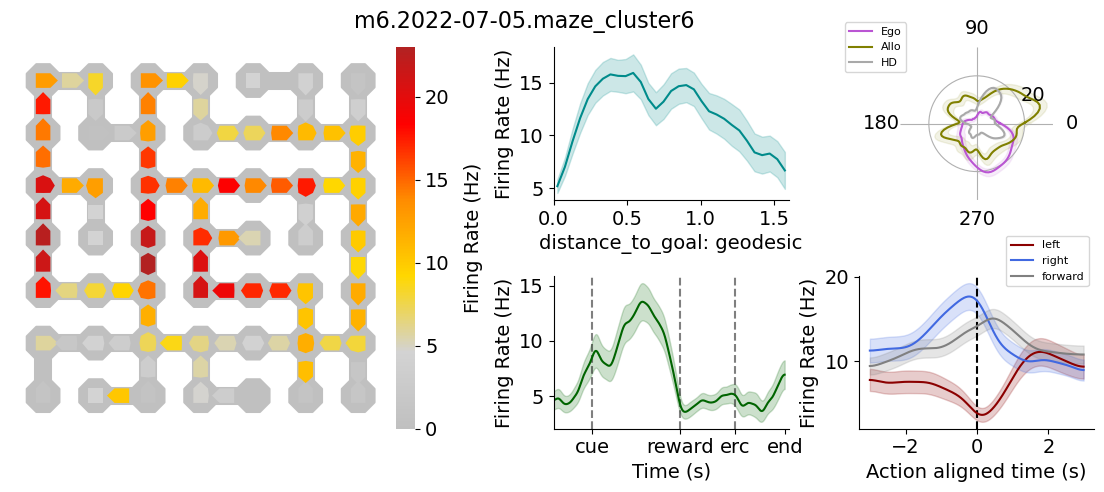

In [12]:
reload(summary)
Cluster = gc.get_cluster("m6.2022-07-05.maze_cluster6")
fig = summary.plot_tuning_summary_concise(Cluster)
fig.savefig("../results/nbeGLM/figures/cluster_tuning_summary.pdf")

In [3]:
from GridMaze.analysis.nbeGLM import load_model_sets as lms
from GridMaze.analysis.nbeGLM import model_comparisons as mc

# model performance validation

baseline vs embedding:
                                       feature_group model_type     t_stat  \
0                                    place_direction  baseline2  11.525828   
1                                    place_direction   baseline  10.305476   
2                   place_direction_distance_to_goal  baseline2  13.474241   
3                   place_direction_distance_to_goal   baseline  11.497903   
4  place_direction_distance_to_goal_egocentric_ac...  baseline2  12.894351   
5  place_direction_distance_to_goal_egocentric_ac...   baseline  11.868882   
6                                              place   baseline   7.882114   

      p_val  p_val_corr  
0  0.000086    0.000122  
1  0.000148    0.000173  
2  0.000040    0.000122  
3  0.000087    0.000122  
4  0.000050    0.000122  
5  0.000075    0.000122  
6  0.000528    0.000528  


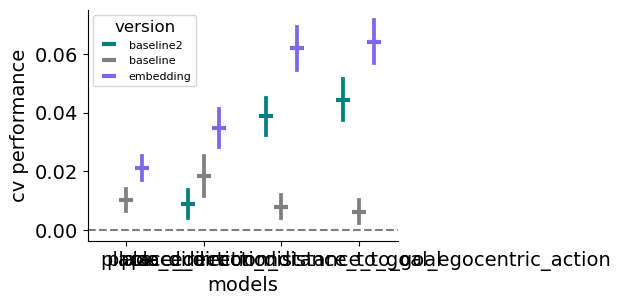

In [22]:
nbe_validation = lms.load_model_set_cv_scores(
    model_set="performance_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=False
)
f, ax = plt.subplots(figsize=(4, 3))
mc.plot_performance_validation(nbe_validation, ax=ax, outlier_threshold=-0.2)
f.savefig("../results/nbeGLM/figures/performance_validation.pdf")

# feature-group interactions validation

In [7]:
interaction_validation_results = lms.load_model_set_cv_scores(
    "interaction_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)

place_direction_linear vs place_direction_nonlinear
t_stat: -4.024459885238532, p_val: 0.010076231225571018
place_direction_distance_to_goal_linear vs place_direction_distance_to_goal_nonlinear
t_stat: 2.881913045778083, p_val: 0.03451091861071185


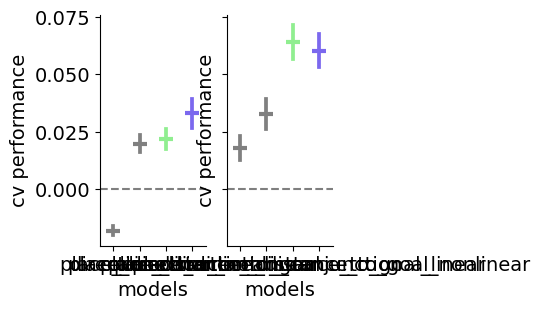

In [25]:
reload(mc)
f, axes = plt.subplots(1, 2, figsize=(3, 3), sharey=True)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=["place", "direction", "place_direction_linear", "place_direction_nonlinear"],
    ax=axes[0],
)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=[
        "place_direction_conjunction",
        "distance_to_goal",
        "place_direction_distance_to_goal_linear",
        "place_direction_distance_to_goal_nonlinear",
    ],
    ax=axes[1],
)
f.savefig("../results/nbeGLM/figures/interaction_validation.pdf")

# unique variance explained

In [9]:
from GridMaze.analysis.nbeGLM import variance_explained as ve

In [10]:
variance_explained_results = lms.load_model_set_cv_scores(
    "variance_explained", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)
reduced_models = [
    "remove_distance_to_goal",
    "remove_place_direction",
    "remove_egocentric_action_action",
]
cpd_df = ve.get_cpd_df(variance_explained_results, reduced_models=reduced_models, outlier_threshold=-0.2)
feature_tuned_df = ve.get_feature_tuned_df(variance_explained_results)

                    feature    t_stat     p_val  p_val_corr
0          distance_to_goal  4.410531  0.003477    0.004790
1  egocentric_action_action  4.075620  0.004790    0.004790
2           place_direction  5.403597  0.001467    0.004401


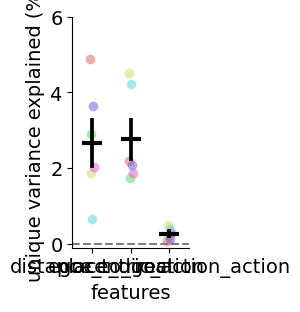

In [ ]:
models = [f.split("_", 1)[-1] for f in reduced_models]
reload(ve)
f, ax = plt.subplots(figsize=(1.5, 3))
ve.plot_variance_explained(cpd_df, features=models, plot_single_subject=True, print_stats=True, ax=ax)
ax.set_ylim(-0.1, 6)
f.savefig("../results/nbeGLM/figures/unique_variance_explained.pdf")

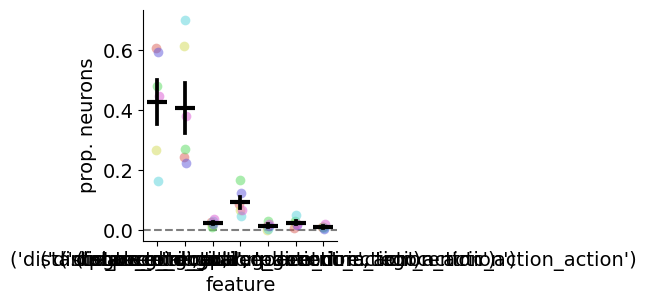

In [15]:
reload(ve)
f, ax = plt.subplots(figsize=(2.5, 3))
ve.plot_summary_pointplot(
    feature_tuned_df,
    models=models,
    ax=ax,
)
f.savefig("../results/nbeGLM/figures/feature_tuning_summary.pdf")

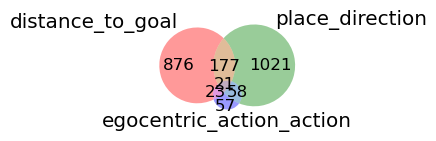

In [16]:
reload(ve)
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
ve.plot_summary_venn_diagram(
    feature_tuned_df,
    models=models,
    ax=ax,
)
fig.savefig("../results/nbeGLM/figures/feature_tuning_venn.pdf")

unique variance explained with more input features

In [38]:
variance_explained_full_results = lms.load_model_set_cv_scores(
    "variance_explained_full",
    maze_names=[
        "maze_1",
        "maze_2",
        "rooms_maze",
    ],
    all_completed=False,
)
reduced_models = [
    "remove_place_direction",
    "remove_distance_to_goal",
    "remove_egocentric_action_free_forced",
    "remove_egocentric_action_action",
    "remove_goal",
    "remove_allocentric_angle_to_goal",
    "remove_egocentric_angle_to_goal",
    "remove_head_direction",
    "remove_speed",
    "remove_acceleration",
]
cpd_full_df = ve.get_cpd_df(variance_explained_full_results, reduced_models=reduced_models, outlier_threshold=-0.2)

                         feature    t_stat     p_val  p_val_corr
0                   acceleration  1.271979  0.129664    0.259328
1      allocentric_angle_to_goal -0.532914  0.691541    0.840510
2               distance_to_goal  1.696770  0.075251    0.188128
3       egocentric_action_action  0.617596  0.281940    0.420272
4  egocentric_action_free_forced  0.577900  0.294190    0.420272
5       egocentric_angle_to_goal -0.749896  0.756459    0.840510
6                           goal -6.326101  0.999273    0.999273
7                 head_direction  8.409511  0.000195    0.001949
8                place_direction  5.264141  0.001644    0.005479
9                          speed  6.244285  0.000772    0.003858


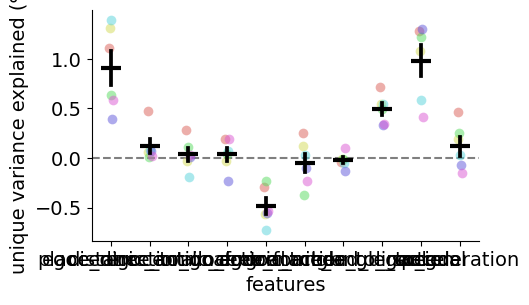

In [39]:
reload(ve)
f, ax = plt.subplots(figsize=(5, 3))
ve.plot_variance_explained(
    cpd_full_df,
    features=[f.split("_", 1)[-1] for f in reduced_models],
    print_stats=True,
    plot_single_subject=True,
    ax=ax,
)
f.savefig("../results/nbeGLM/figures/unique_variance_explained_full.pdf")

# main feature interactions 

In [18]:
main_feature_interactions = lms.load_model_set_cv_scores(
    "main_feature_interactions",
    maze_names=["maze_1", "maze_2", "rooms_maze"],
    all_completed=True,
)

                                             model_1  \
0  place-direction-distance_to_goal-egocentric_ac...   
1  place-direction-distance_to_goal-egocentric_ac...   
2  place.direction-distance_to_goal-egocentric_ac...   

                                             model_2    t_stat     p_val  \
0  place.direction-distance_to_goal-egocentric_ac... -3.249279  0.022714   
1  place.direction.distance_to_goal.egocentric_ac... -3.119532  0.026266   
2  place.direction.distance_to_goal.egocentric_ac...  2.222501  0.076886   

   p_val_corr  
0    0.039399  
1    0.039399  
2    0.076886  


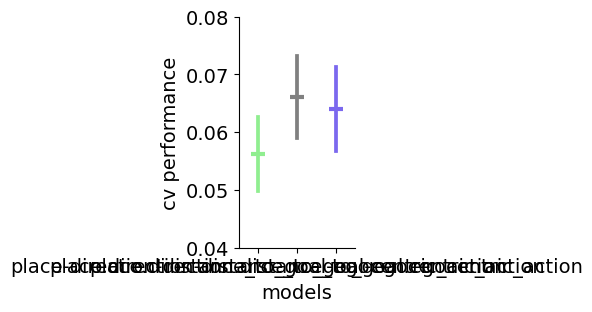

In [24]:
reload(mc)
f, ax = plt.subplots(figsize=(1.5, 3))
mc.plot_main_feature_interactions(main_feature_interactions, plot_single_subjects=False, outlier_threshold=-0.2, ax=ax)
ax.set_ylim(0.04, 0.08)
f.savefig("../results/nbeGLM/figures/main_feature_interactions.pdf")

# visualising embedding latent tuning

In [41]:
from GridMaze.maze import representations as mr
from GridMaze.analysis.nbeGLM import vis_latents as vl

In [82]:
model_name = "full_model"
maze_name = "maze_2"
latent_tuning_dfs = vl.get_latent_tuning_dfs(model_name=model_name, maze_name=maze_name)
simple_maze = mr.get_simple_maze(maze_name)

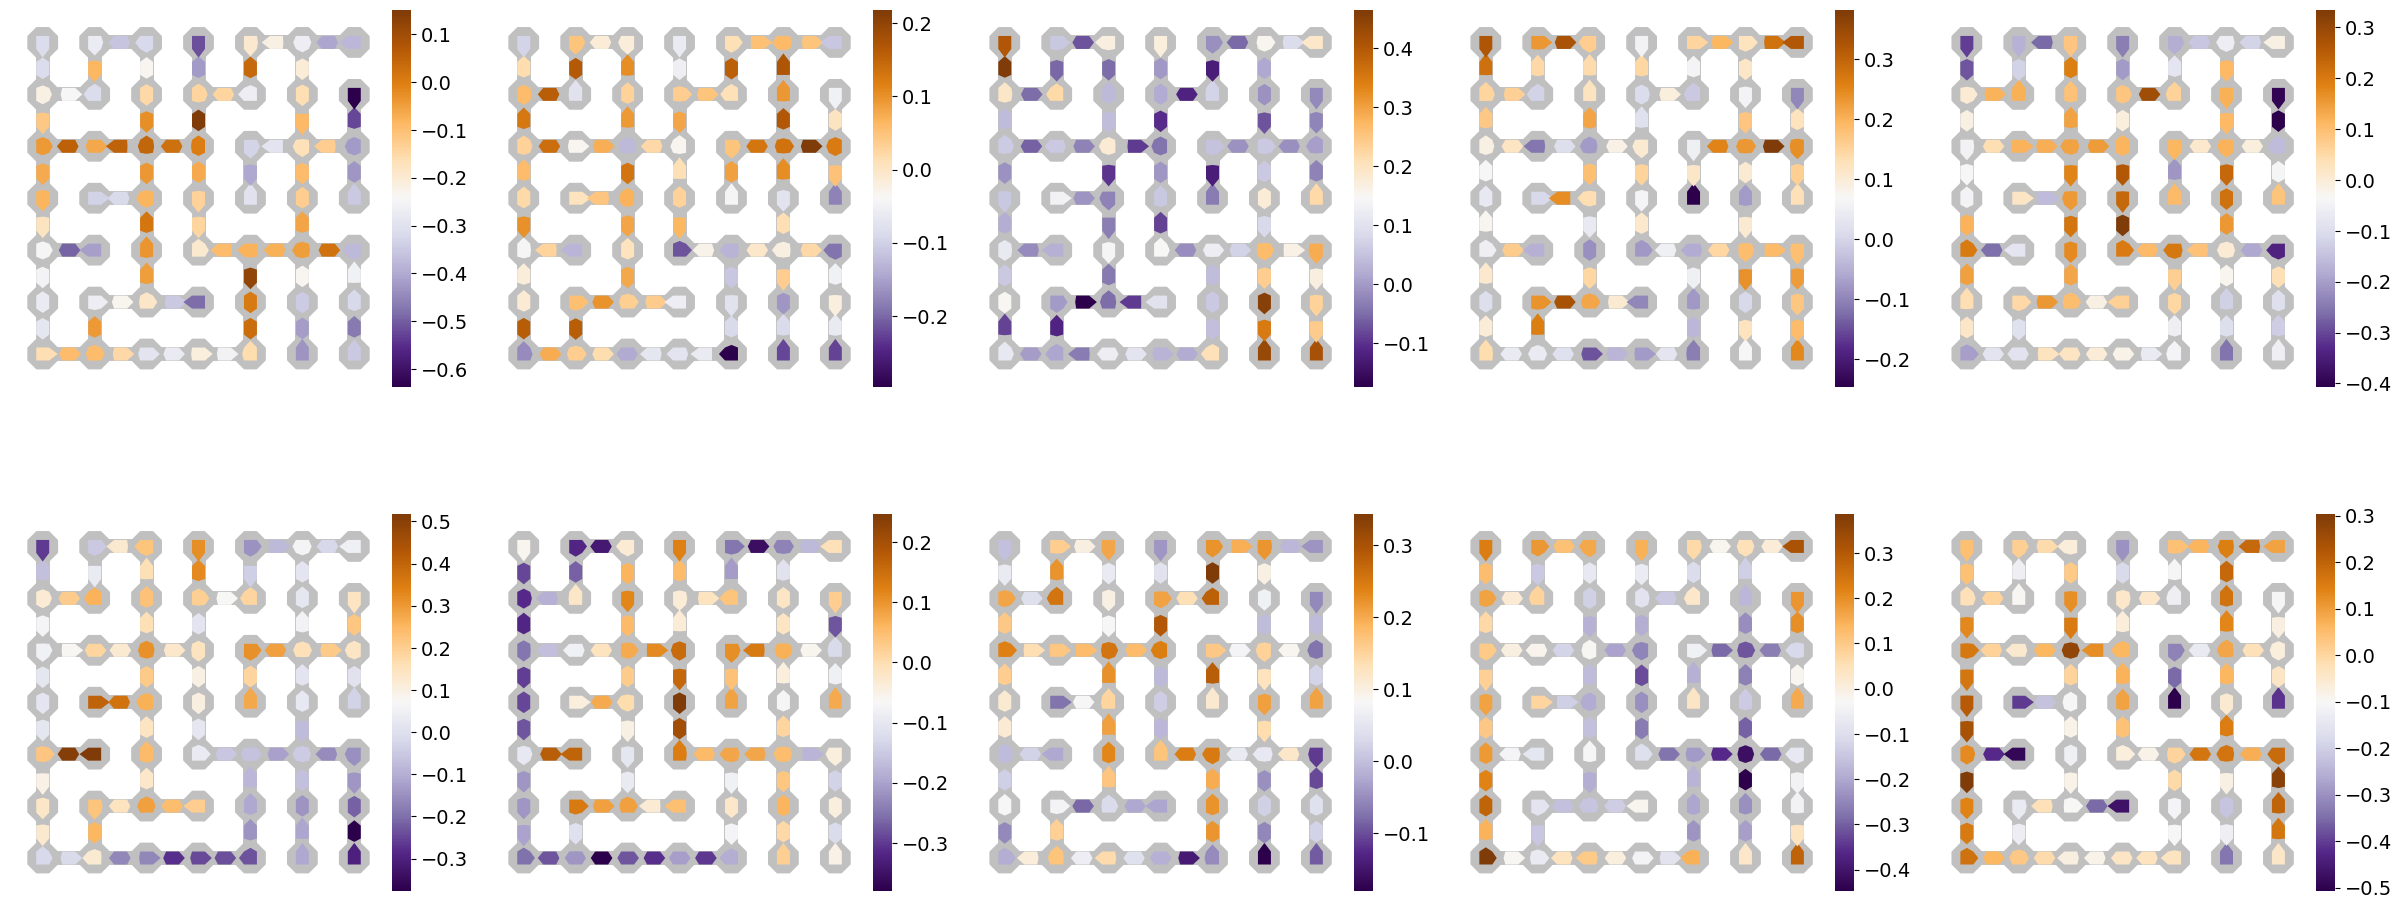

In [83]:
reload(vl)
f, axes = plt.subplots(2, 5, figsize=(30, 12))
vl.plot_latent_place_direction_tuning(latent_tuning_dfs["place_direction"], simple_maze, axes=axes)
f.savefig("../results/nbeGLM/figures/latent_place_direction_tuning.pdf")

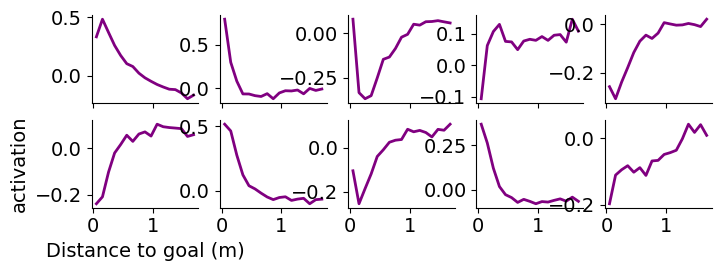

In [84]:
reload(vl)
f, axes = plt.subplots(2, 5, figsize=(8, 2.5), sharex=True)
vl.plot_latent_distance_to_goal_tuning(latent_tuning_dfs["distance_to_goal"], axes=axes)
f.savefig("../results/nbeGLM/figures/latent_distance_to_goal_tuning.pdf")

# population tuning summaries revisted

In [8]:
from GridMaze.analysis.nbeGLM import tuning_summaries as ts
from GridMaze.maze import representations as mr

In [5]:
# distance tuning
distance_tuning_df = ts.get_population_unique_distance_to_goal_tuning_df()

frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


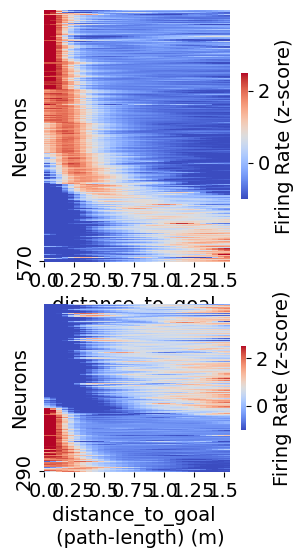

In [16]:
# plot
f, axes = plt.subplots(2, 1, figsize=(3, 6), height_ratios=[1.5, 1])
ts.plot_unique_distance_to_goal_tuning_heatmap(distance_tuning_df, axes=axes)
f.savefig("../results/nbeGLM/figures/unique_distance_tuning_heatmap.pdf")

frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.placeDirectionTuningMetrics.parquet not found for m8.2022-07-26.maze


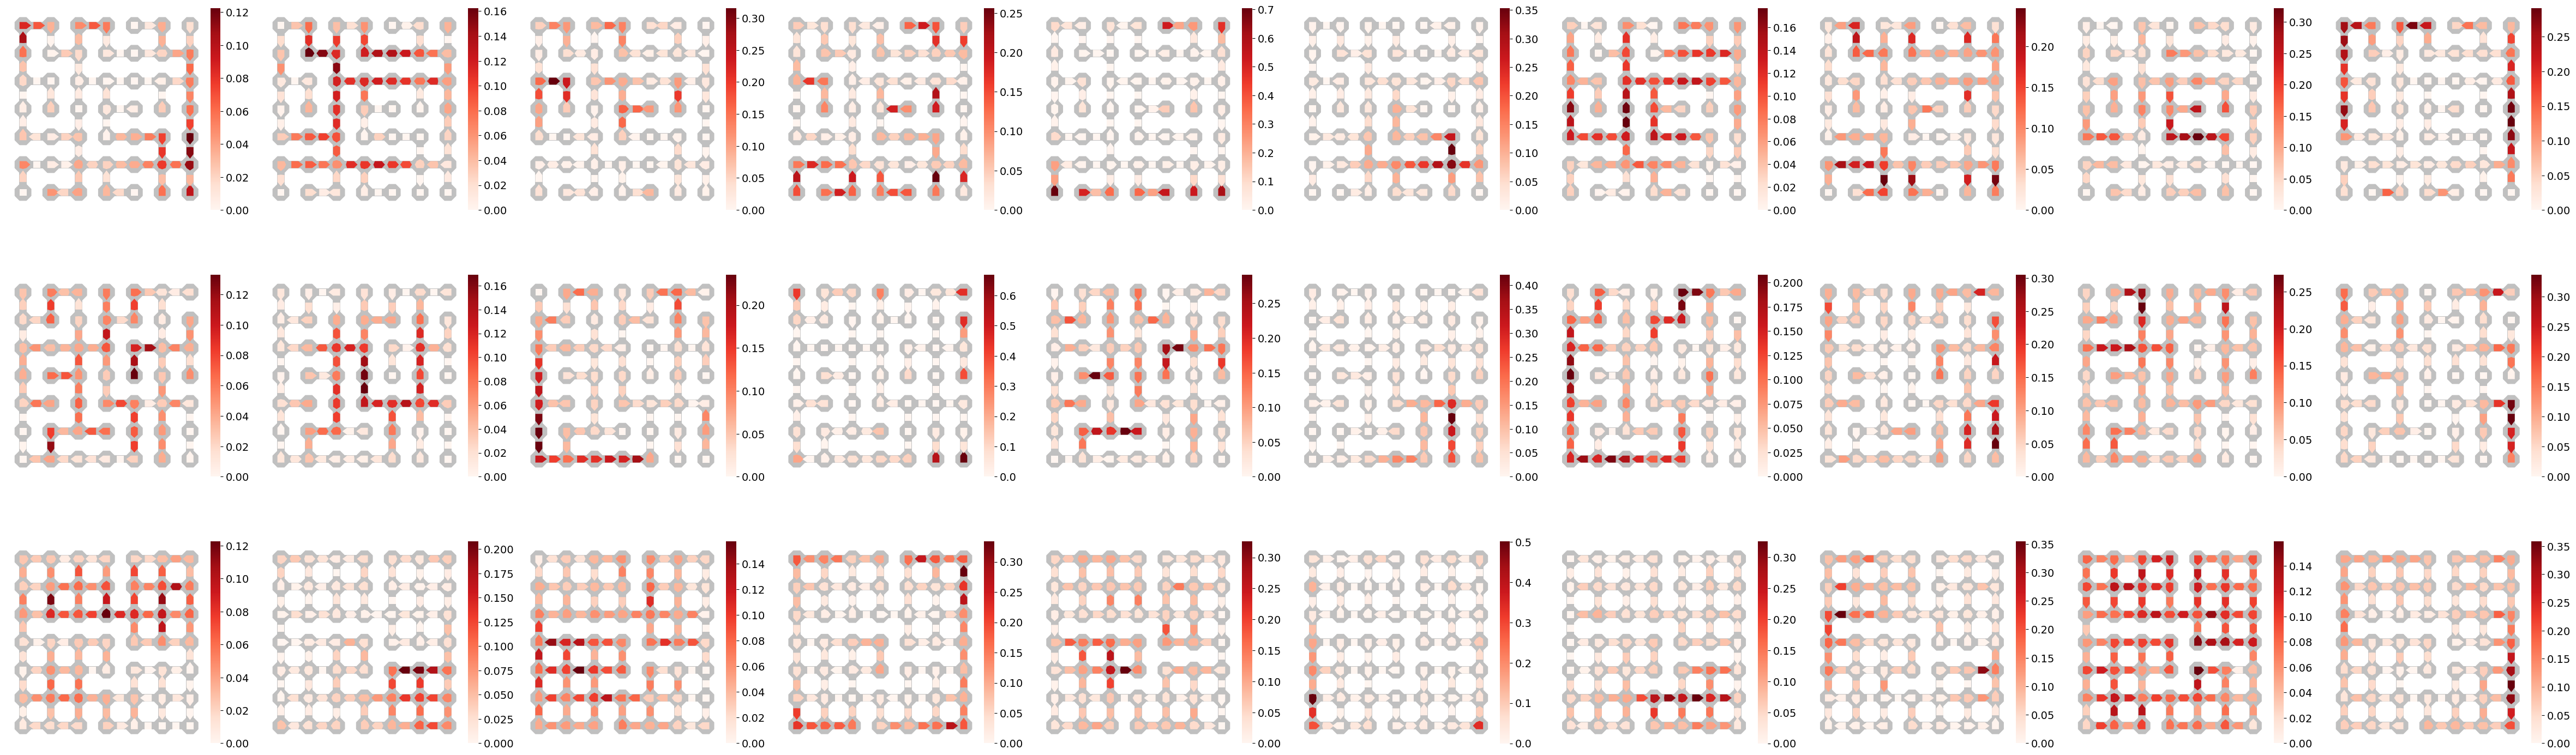

In [17]:
# place-direction tuning
dim_red = "nmf"
n_components = 10
f, axes = plt.subplots(3, n_components, figsize=(6 * n_components, 18))
for i, maze_name in enumerate(["maze_1", "maze_2", "rooms_maze"]):
    simple_maze = mr.get_simple_maze(maze_name)
    place_direction_tuning_df = ts.get_population_unique_place_direction_tuning_df(maze_name=maze_name)
    ts.plot_unique_place_direction_components(
        place_direction_tuning_df, simple_maze, dim_red=dim_red, n_components=n_components, axes=axes[i, :]
    )
f.savefig(f"../results/nbeGLM/figures/unique_place_direction_{dim_red}_components.pdf")